> Quick Run (at the top)
> - Edit `my_config` in the next code cell
> - Run it to immediately refresh the plots
> - Other cells below are optional

[700000, 300000] [0.5, 0.3] [[3, 2], [3, 1]]
Running Equal, Proportion, and Utility scenarios...
Running Fair scenarios...
All allocation results saved to d:\python_workspace\mask_distribution\실험\output\df_results_output_pop800000_400000_aged0.5_0.25_slope3_2_5_1.csv
Converting allocation results to policy.txt for SEIRD model...
Successfully created d:\python_workspace\mask_distribution\실험\input\policy.csv
SEIRD model results saved to d:\python_workspace\mask_distribution\실험\output\policy_results_with_priority_pop800000_400000_aged0.5_0.25_slope3_2_5_1.csv
Results accumulated to d:\python_workspace\mask_distribution\실험\output\policy_results_with_priority_accumulated.csv


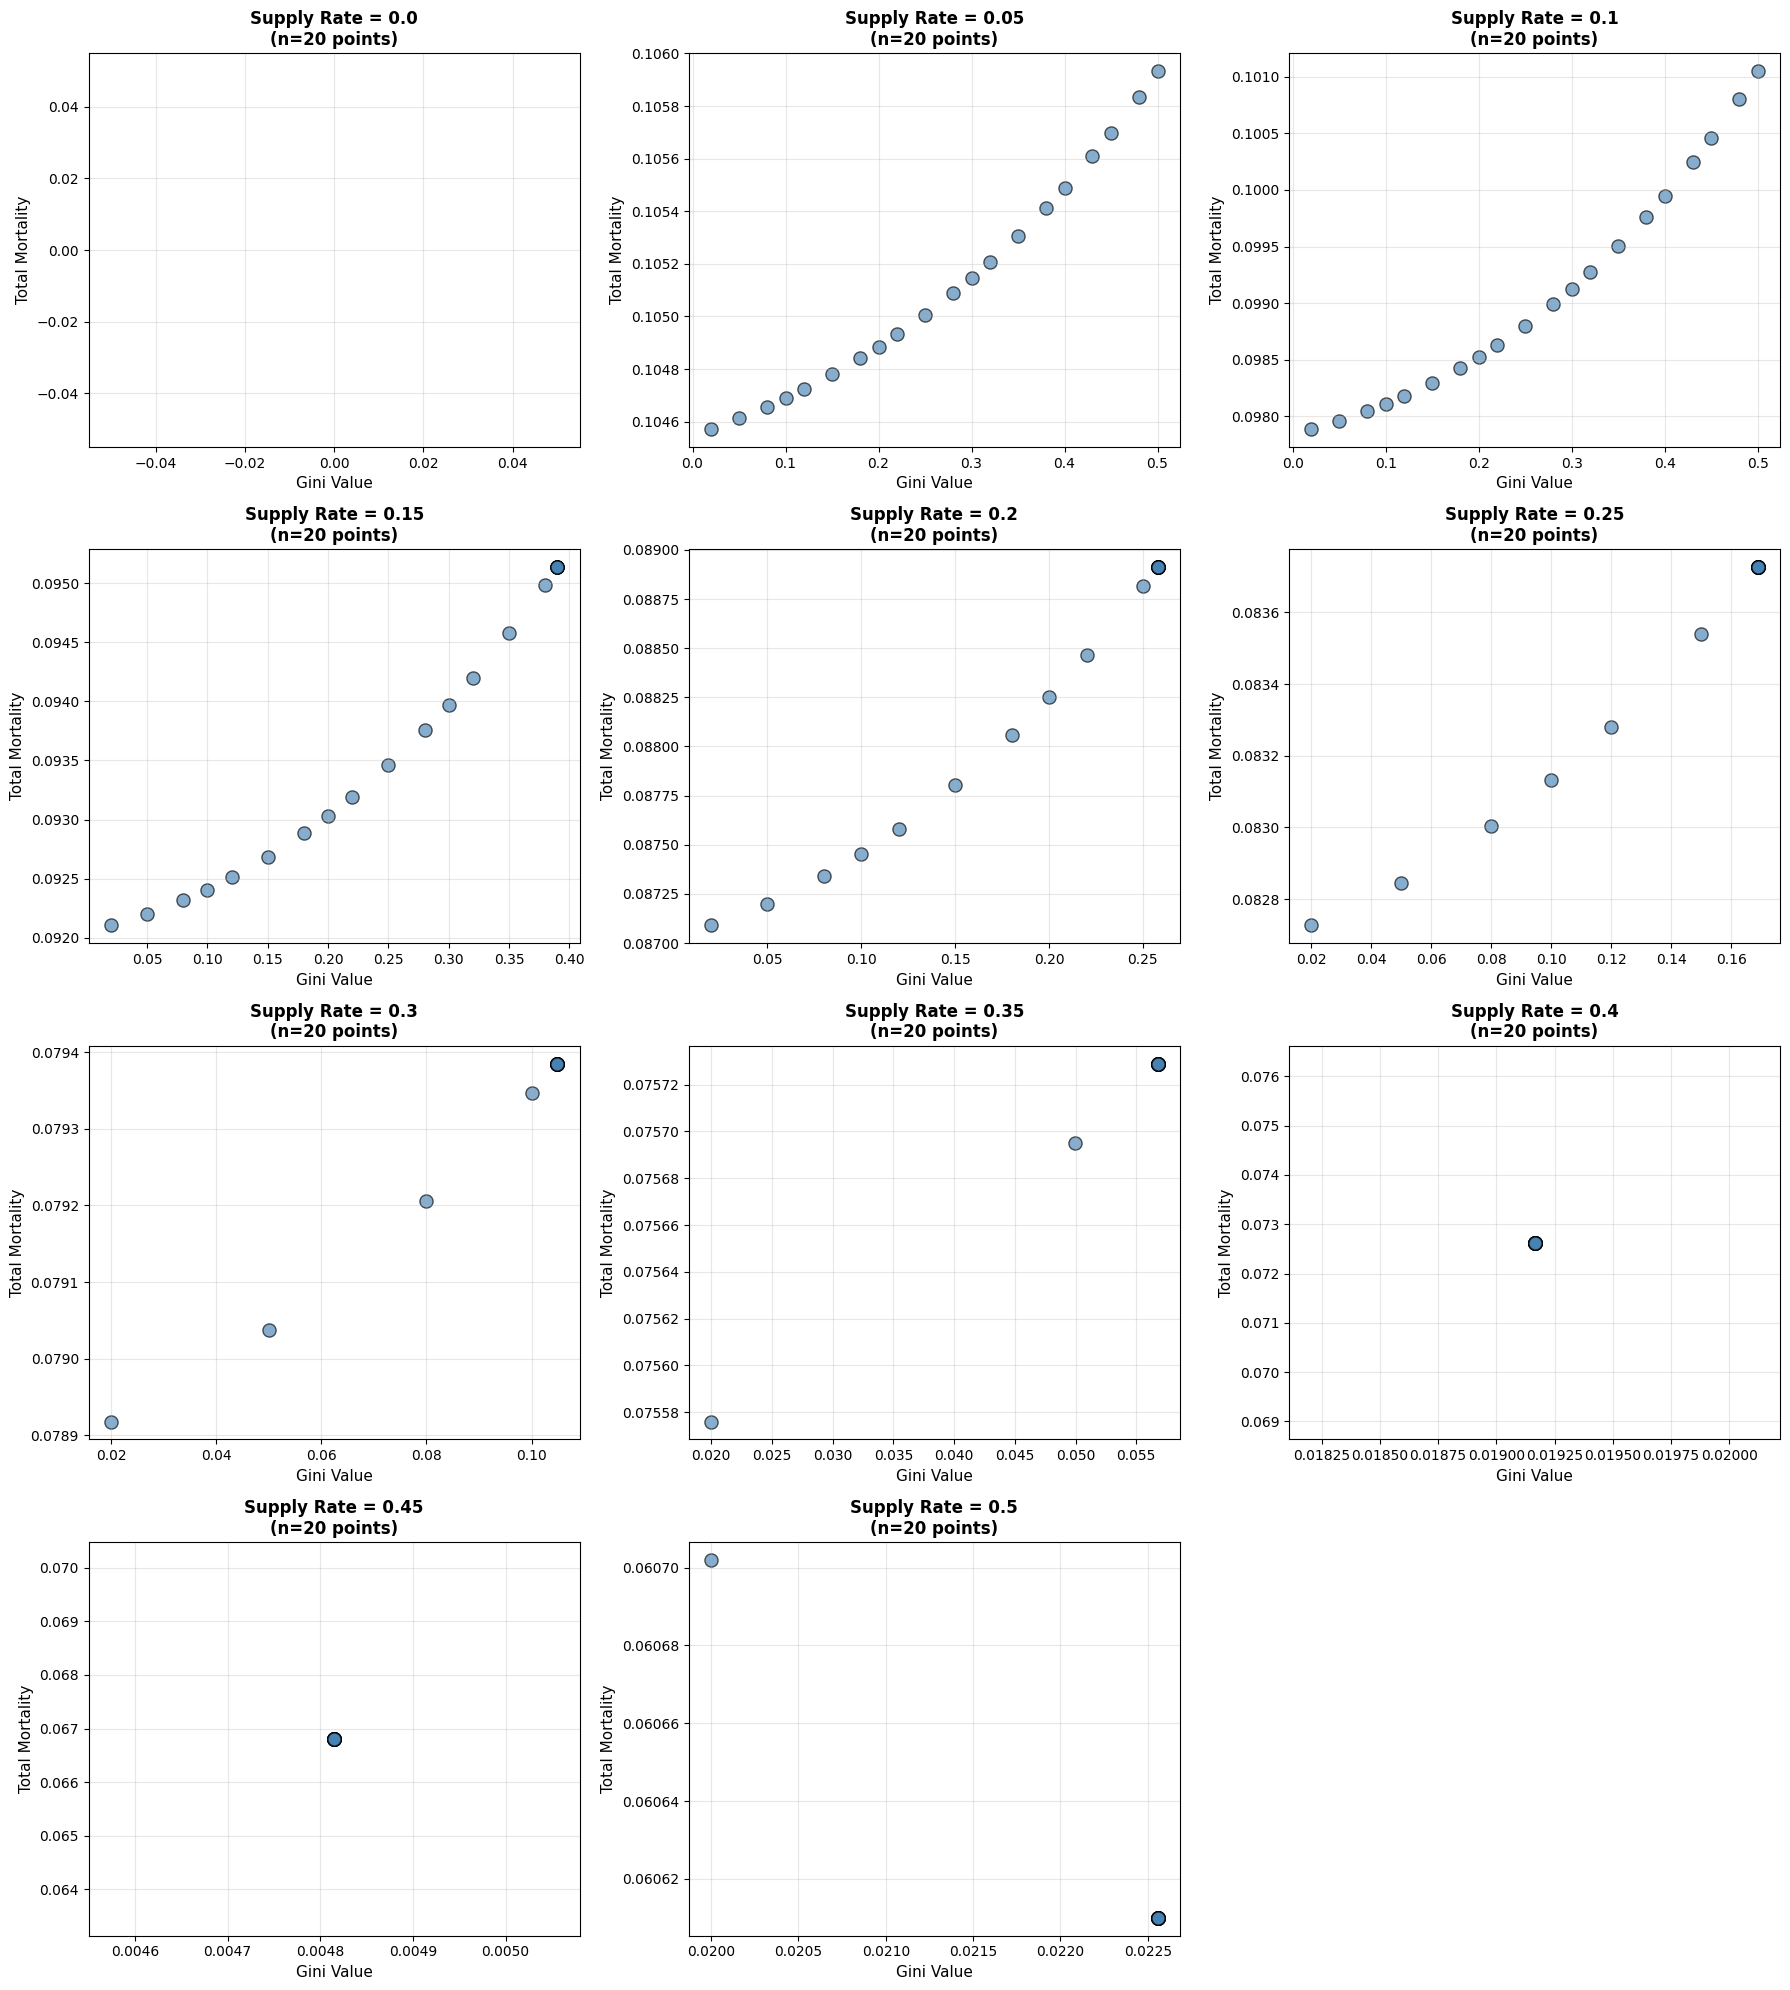

In [1]:
# Quick Run: edit my_config below, then run this cell to see the plot immediately
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure local imports work
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.getcwd()
sys.path.append(SCRIPT_DIR)

import quick_systematic_experiment as qse
import conditions as cnd
import allocate_masks as alloc
import utils
import seird_model as seird

# --- Edit here: configuration ---
my_config = {
    'populations': (800000, 400000),
    'aged_ratio': (0.5, 0.25),
    'slopes': (3, 2, 5, 1)  # (aged_r1, nonaged_r1, aged_r2, nonaged_r2)
}

# Update conditions
pop_r1, pop_r2 = my_config['populations']
aged_r1, aged_r2 = my_config['aged_ratio']
slope_aged_r1, slope_nonaged_r1, slope_aged_r2, slope_nonaged_r2 = my_config['slopes']
qse.update_conditions(pop_r1, pop_r2, aged_r1, aged_r2,
                      slope_aged_r1, slope_nonaged_r1,
                      slope_aged_r2, slope_nonaged_r2)

# Run pipeline (in-memory)
allocation_df = alloc.run_allocation_scenarios()
policy_df = utils.convert_df(allocation_df)
results_df = seird.run_dynamic_experiment(policy_df)

# Merge R1/R2 quantities
policy_df_with_qty = policy_df.rename(columns={'region1_masks': 'R1_qty', 'region2_masks': 'R2_qty'})
policy_df_with_qty['policy_key'] = policy_df_with_qty['policy_name']
results_df['policy_key'] = results_df.apply(
    lambda row: f"{row['policy']}_{row['supply_rate']}_{row['epsilon']}" if row['policy']=='Fair' and pd.notna(row['epsilon'])
                else f"{row['policy']}_{row['supply_rate']}",
    axis=1
)
results_df = results_df.merge(policy_df_with_qty[['policy_key','R1_qty','R2_qty']], on='policy_key', how='left')
results_df.drop(columns=['policy_key'], inplace=True)

# Reorder columns
qty_cols = ['R1_qty', 'R2_qty']
key_cols = ['epsilon', 'Gini_Value', 'Total_Mortality']
final_cols = []
for col in results_df.columns:
    if col in qty_cols or col in key_cols:
        continue
    final_cols.append(col)
    if col == 'policy':
        final_cols.extend([c for c in qty_cols if c in results_df.columns])
    elif col == 'supply_rate':
        final_cols.extend([c for c in key_cols if c in results_df.columns])
results_df_display = results_df[final_cols]

# Plot Fair policy by unique supply_rate
fair_df = results_df_display[results_df_display['policy'] == 'Fair'].copy()
supply_rates = sorted(fair_df['supply_rate'].unique())

n_cols = min(3, max(1, len(supply_rates)))
n_rows = (len(supply_rates) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))

if len(supply_rates) == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes
else:
    axes = axes.flatten()

for idx, rate in enumerate(supply_rates):
    data = fair_df[fair_df['supply_rate'] == rate]
    axes[idx].scatter(data['Gini_Value'], data['Total_Mortality'], alpha=0.65, s=90, c='steelblue', edgecolors='black')
    axes[idx].set_xlabel('Gini Value', fontsize=11)
    axes[idx].set_ylabel('Total Mortality', fontsize=11)
    axes[idx].set_title(f'Supply Rate = {rate}\n(n={len(data)} points)', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(supply_rates), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import importlib
import interactive_explorer_simple as ies
importlib.reload(ies)
explorer = ies.create_explorer()
explorer.display()

🔬 Interactive Configuration Explorer (Simple)
Population range: 10-100 (×10,000)
All configurations computed on-demand (~1-5 seconds)

